In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
ev_data = pd.read_csv("../data/heavy_user.csv")
ev_data

,Unnamed: 0,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Charging_Voltage,Tire_Pressure,DTC
0,2020-01-01 00:00:00,20.000000,99.999757,0,31.822998,0.0,0.0,64.937230,100.000000,400,34.987175,0
1,2020-01-01 01:00:00,20.000000,99.999495,0,31.596741,0.0,0.0,71.637683,100.000000,400,34.976006,0
2,2020-01-01 02:00:00,20.000000,99.999244,0,31.694791,0.0,0.0,76.626964,100.000000,400,34.961510,0
3,2020-01-01 03:00:00,20.000000,99.998996,0,29.370583,0.0,0.0,73.446945,100.000000,400,34.949125,0
4,2020-01-01 04:00:00,20.000000,99.998749,0,30.808790,0.0,0.0,70.240659,100.000000,400,34.935932,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.0,0.0,73.274256,57.599885,400,29.247296,0
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.0,0.0,71.116980,57.599885,400,29.235478,0
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.0,0.0,71.968694,57.599885,400,29.220806,0
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.0,0.0,70.822133,57.599885,400,29.209373,0


In [3]:
# give the timestamp column a name
ev_data.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)

In [4]:
# convert the timestamps to datetime objects such that we can make comparisons
ev_data["TimeStamp"] = pd.to_datetime(ev_data["TimeStamp"])

In [5]:
# the charging voltage is a constant so not informative for the AI models (this step should be part of the pipeline)
ev_data.drop("Charging_Voltage", axis=1, inplace=True)
ev_data

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,DTC
0,2020-01-01 00:00:00,20.000000,99.999757,0,31.822998,0.0,0.0,64.937230,100.000000,34.987175,0
1,2020-01-01 01:00:00,20.000000,99.999495,0,31.596741,0.0,0.0,71.637683,100.000000,34.976006,0
2,2020-01-01 02:00:00,20.000000,99.999244,0,31.694791,0.0,0.0,76.626964,100.000000,34.961510,0
3,2020-01-01 03:00:00,20.000000,99.998996,0,29.370583,0.0,0.0,73.446945,100.000000,34.949125,0
4,2020-01-01 04:00:00,20.000000,99.998749,0,30.808790,0.0,0.0,70.240659,100.000000,34.935932,0
...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.0,0.0,73.274256,57.599885,29.247296,0
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.0,0.0,71.116980,57.599885,29.235478,0
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.0,0.0,71.968694,57.599885,29.220806,0
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.0,0.0,70.822133,57.599885,29.209373,0


In [6]:
# here we can see that it is likely that the battery has been replaced multiple times as Charging_Cycles is set to 0 on multiple occassions
fig = px.line(ev_data, x="TimeStamp", y="Charging_Cycles", title="Number of charging cycles of the EV")
fig.show()

In [7]:
# here we can see that one specific dtc(P0B) is connected to the battery as when battery cycles is reset to 0, there was a DTC during that time except for one case  
fig = px.line(ev_data, x="TimeStamp", y="DTC", title="Diagnostic Trouble Code")
fig.show()

In [8]:
# one case where the health of the battery 
fig = px.line(ev_data, x="TimeStamp", y="SOH", title="State of Health (Battery)")
fig.show()

In [9]:
ev_data_2021_oct = ev_data[(ev_data["TimeStamp"].dt.year == 2021) & (ev_data["TimeStamp"].dt.month == 10)]
fig = px.line(ev_data_2021_oct, x="TimeStamp", y="SOC", title="State of Charge (Battery)")
fig.show()

In [10]:
# daily pattern is visible
fig = px.line(ev_data_2021_oct, x="TimeStamp", y="Motor_Torque", title="The Torque of the Motor")
fig.show()

In [11]:
# pattern seems to repeats around 23-24 days, 4 dec 2021 we see a sudden drop in pressure which coincides with a DTC
ev_data_2021 = ev_data[ev_data["TimeStamp"].dt.year == 2021]
fig = px.line(ev_data_2021, x="TimeStamp", y="Tire_Pressure", title="The Tire Pressure")
fig.show()

In [12]:
# TODO: add a feature representing the month/season based on the timestamp

In [13]:
# what we might be able to do is create individual models for some features that have clear periodical behaviour, we can see for example a clear pattern in state of charge,
# etc but for some the sampling frequency of an hour is not high enough as this should be at least 2 times the highest frequency of the signal according to the "Nyquist-Shannon sampling theorem"
# e.g., the motor torque has a daily pattern i.e. nonzero torque during day and zero torque during night. However, other patterns during driving are probably not captured by the
# hourly sampling rate. If i want to have some univariate models to obtain anomaly info only on a specific feature: https://blog.jetbrains.com/pycharm/2025/01/anomaly-detection-in-time-series/
# one of the advantages of the ML approaches such as isolation forrest and multivariate autoencoders is that you can also see anomalies caused by the combination of multiple 
# features

In [14]:
#check the data where there is a DTC
ev_data[ev_data["DTC"] != "0"]

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,DTC
64,2020-01-03 16:00:00,100.000000,99.972906,2,29.634989,1395.020488,279.004098,69.994426,99.517249,34.195862,P0MR
133,2020-01-06 13:00:00,54.408731,99.950915,2,28.602932,1340.043911,268.008782,69.906038,99.255273,33.341432,P0MR
153,2020-01-07 09:00:00,35.514163,99.943888,2,32.547141,1325.271854,265.054371,68.554872,99.146239,33.101870,P0MR
202,2020-01-09 10:00:00,56.786750,99.924500,3,32.336645,1388.915325,277.783065,73.582733,98.803817,32.508910,P0MR
226,2020-01-10 10:00:00,28.344328,99.915479,3,30.550705,1293.170534,258.634107,66.106977,98.641303,32.213739,P0MR
...,...,...,...,...,...,...,...,...,...,...,...
43662,2024-12-24 06:00:00,97.845707,90.168801,28,36.269131,1399.620407,279.924081,70.508301,58.375664,30.887573,P0MR
43670,2024-12-24 14:00:00,78.927723,90.164746,28,31.639869,1333.152236,266.630447,71.446839,58.267073,30.790935,P0MR
43692,2024-12-25 12:00:00,54.775454,90.156814,28,36.543151,1352.380854,270.476171,65.474802,58.131868,30.517928,P0MR
43740,2024-12-27 12:00:00,77.541319,90.137773,29,36.062278,4604.708704,920.941741,105.380612,57.801716,29.933706,P0MT


In [15]:
# obtain list with features that need rolling window and lag features
features_excluded = ["DTC", "TimeStamp"]
ev_reduced_cols = [col for col in ev_data.columns if col not in features_excluded]
ev_reduced_cols

['SOC',
 'SOH',
 'Charging_Cycles',
 'Battery_Temp',
 'Motor_RPM',
 'Motor_Torque',
 'Motor_Temp',
 'Brake_Pad_Wear',
 'Tire_Pressure']

In [16]:
#this is only for the training and testing of the model for runtime predictions we need to obtain the lag features via the historical states in the digital twin
# here we can just shift the columns because we already have the full dataset.

#TODO: morgen even overleggen of we dit erin houden of niet

# set the size for the lag and window features
window_lag_size = 100

#
for col in ev_reduced_cols:
     
     # add the rolling features
     ev_data[f"{col}_rolling-{window_lag_size}_std"] = ev_data[col].rolling(window=window_lag_size, min_periods=window_lag_size).std()
     ev_data[f"{col}_rolling-{window_lag_size}_mean"] = ev_data[col].rolling(window=window_lag_size, min_periods=window_lag_size).mean()
     
     # add the lag features
     for i in range(1, window_lag_size + 1):
        ev_data[f"{col}_lag-{i}"] = ev_data[col].shift(i)


# this drops the first window_lag_size rows/hours of data because the lag features have missing values because there is not enough historical data available yet
ev_data.dropna(inplace=True)

ev_data




C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\533950948.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\533950948.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\533950948.py:18: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 

,TimeStamp,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,...,Tire_Pressure_lag-91,Tire_Pressure_lag-92,Tire_Pressure_lag-93,Tire_Pressure_lag-94,Tire_Pressure_lag-95,Tire_Pressure_lag-96,Tire_Pressure_lag-97,Tire_Pressure_lag-98,Tire_Pressure_lag-99,Tire_Pressure_lag-100
100,2020-01-05 04:00:00,85.736755,99.962454,2,28.634138,0.0,0.0,68.878000,99.437546,33.759069,...,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510,34.976006,34.987175
101,2020-01-05 05:00:00,85.736755,99.962195,2,31.194405,0.0,0.0,69.768201,99.437546,33.744549,...,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510,34.976006
102,2020-01-05 06:00:00,85.736755,99.961955,2,30.163521,0.0,0.0,72.430783,99.437546,33.732151,...,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125,34.961510
103,2020-01-05 07:00:00,85.736755,99.961704,2,27.356774,0.0,0.0,70.103744,99.437546,33.717516,...,34.836012,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932,34.949125
104,2020-01-05 08:00:00,85.736755,99.961442,2,31.025271,0.0,0.0,73.453923,99.437546,33.707425,...,34.825971,34.836012,34.846403,34.860275,34.872329,34.887148,34.901871,34.913757,34.924030,34.935932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2024-12-29 19:00:00,41.896804,90.120302,29,30.644411,0.0,0.0,73.274256,57.599885,29.247296,...,30.371451,30.384932,30.395839,30.407697,30.417830,30.428892,30.440605,30.451045,30.464300,30.478550
43796,2024-12-29 20:00:00,41.896804,90.120050,29,31.478640,0.0,0.0,71.116980,57.599885,29.235478,...,30.357372,30.371451,30.384932,30.395839,30.407697,30.417830,30.428892,30.440605,30.451045,30.464300
43797,2024-12-29 21:00:00,41.896804,90.119788,29,28.318739,0.0,0.0,71.968694,57.599885,29.220806,...,30.345688,30.357372,30.371451,30.384932,30.395839,30.407697,30.417830,30.428892,30.440605,30.451045
43798,2024-12-29 22:00:00,41.896804,90.119528,29,30.484194,0.0,0.0,70.822133,57.599885,29.209373,...,30.333155,30.345688,30.357372,30.371451,30.384932,30.395839,30.407697,30.417830,30.428892,30.440605


In [17]:
n_months = 12
n_days = 7
n_hours = 24

# extract series containing temporal info, i.e. month day of the week, and the hour
months = ev_data["TimeStamp"].dt.month
days = ev_data["TimeStamp"].dt.dayofweek
hours = ev_data["TimeStamp"].dt.hour

# To maintain some temporal information we do cyclic encoding on the month day and hour extracted from the timestamp. This is cleaner and represents the cyclic pattern better.
# Both the sine and cosine necessary to maintain the full info 
ev_data["Cosine_Month"] = np.cos((2 * np.pi / n_months) * months)
ev_data["Sine_Month"] = np.sin((2 * np.pi / n_months) * months)

ev_data["Cosine_Day"] = np.cos((2 * np.pi / n_days) * days)
ev_data["Sine_Day"] = np.sin((2 * np.pi / n_days) * days)

ev_data["Cosine_Hour"] = np.cos((2 * np.pi / n_hours) * hours)
ev_data["Sine_Hour"] = np.sin((2 * np.pi / n_hours) * hours)


ev_data_reduced = ev_data.drop(columns=["DTC", "TimeStamp"])

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1787377.py:12: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1787377.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1787377.py:15: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame,

In [18]:
# (maybe include a season feature later,i.e. summer/winter/fall/spring and maybe additional features based on time, e.g. hour of the day, weekend etc) normalize the data, 
# train/test split of ev_data_reduced and then train the isolation forrest.

In [19]:
# feature design based on domain knowledge

# small value to prevent divisions by zero
safe_div = 1e-4

# captures ratio between the temperature and the torque of the motor
ev_data_reduced["Temp_Torque"] =  ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Motor_Torque"] + safe_div)

# captures ratio between the temperature and the RPM of the motor
ev_data_reduced["Temp_RPM"] =  ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Motor_RPM"] + safe_div)

# captures ratio between temperature and state of health of the battery
ev_data_reduced["Temp_Health"] =  ev_data_reduced["Battery_Temp"] / (ev_data_reduced["SOH"] + safe_div)

#  captures temperature ratio between motor and battery
ev_data_reduced["Temp_Ratio"] = ev_data_reduced["Motor_Temp"] / (ev_data_reduced["Battery_Temp"] + safe_div)

# captures ratio between the temperature and state of charge of the battery
ev_data_reduced["Temp_Charge"] =  ev_data_reduced["Battery_Temp"] / (ev_data_reduced["SOC"] + safe_div)

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1835505824.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1835505824.py:10: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1835505824.py:13: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmente

In [20]:
# normalizing the data using the robustscaler as we do have outliers in the data that we do not remove.
scaler = RobustScaler().fit(ev_data_reduced)
scaled_data = scaler.transform(ev_data_reduced)
scaled_df = pd.DataFrame(scaled_data, columns=ev_data_reduced.columns)
scaled_df

,SOC,SOH,Charging_Cycles,Battery_Temp,Motor_RPM,Motor_Torque,Motor_Temp,Brake_Pad_Wear,Tire_Pressure,SOC_rolling-100_std,...,Sine_Month,Cosine_Day,Sine_Day,Cosine_Hour,Sine_Hour,Temp_Torque,Temp_RPM,Temp_Health,Temp_Ratio,Temp_Charge
0,0.624445,1.107523,-0.765957,-0.314132,0.0,0.0,-0.360792,0.936383,1.487106,0.712125,...,0.366025,0.554958,-0.5,3.535534e-01,0.612372,0.029398,0.029398,-0.521284,0.354756,-0.538718
1,0.624445,1.107478,-0.765957,-0.041226,0.0,0.0,-0.195907,0.936383,1.482996,0.603219,...,0.366025,0.554958,-0.5,1.830127e-01,0.683013,0.042017,0.042017,-0.249972,-0.013763,-0.472527
2,0.624445,1.107436,-0.765957,-0.151110,0.0,0.0,0.297262,0.936383,1.479487,0.487891,...,0.366025,0.554958,-0.5,1.731912e-16,0.707107,0.079761,0.079761,-0.359204,0.345637,-0.499179
3,0.624445,1.107392,-0.765957,-0.450289,0.0,0.0,-0.133757,0.936383,1.475344,0.365724,...,0.366025,0.554958,-0.5,-1.830127e-01,0.683013,0.046773,0.046773,-0.656620,0.697602,-0.571743
4,0.624445,1.107346,-0.765957,-0.059254,0.0,0.0,0.486770,0.936383,1.472488,0.236236,...,0.366025,0.554958,-0.5,-3.535534e-01,0.612372,0.094264,0.094264,-0.267870,0.272061,-0.476900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43695,-0.466659,-0.614532,-0.478723,-0.099851,0.0,0.0,0.453491,-0.311455,0.210066,-0.322790,...,0.000000,0.554958,-0.5,1.830127e-01,-0.683013,0.091717,0.091717,0.046378,0.323473,0.342257
43696,-0.466659,-0.614577,-0.478723,-0.010928,0.0,0.0,0.053916,-0.311455,0.206721,-0.315937,...,0.000000,0.554958,-0.5,3.535534e-01,-0.612372,0.061137,0.061137,0.144443,0.035665,0.386392
43697,-0.466659,-0.614622,-0.478723,-0.347751,0.0,0.0,0.211672,-0.311455,0.202568,-0.313446,...,0.000000,0.554958,-0.5,5.000000e-01,-0.500000,0.073210,0.073210,-0.226961,0.651359,0.219216
43698,-0.466659,-0.614668,-0.478723,-0.116929,0.0,0.0,-0.000696,-0.311455,0.199331,-0.310958,...,0.000000,0.554958,-0.5,6.123724e-01,-0.353553,0.056957,0.056957,0.027577,0.175374,0.333780


In [21]:
# train en test split without shuffle to keep the order intact
X_train, X_test = train_test_split(scaled_df, test_size=0.2, shuffle=False)


In [22]:
clf = IsolationForest(random_state=0, contamination=0.03).fit(X_train)
preds = clf.predict(X_test)
preds

array([1, 1, 1, ..., 1, 1, 1], shape=(8740,))

In [23]:
scores = clf.decision_function(X_test)
scores

array([0.06525622, 0.08368784, 0.07063679, ..., 0.08563138, 0.08118729,
       0.08452362], shape=(8740,))

In [24]:
# to visualize the anomalies we want to add the anomalies to the original data and therefore we split the original data 
ev_train, ev_test = train_test_split(ev_data, test_size=0.2, shuffle=False)

In [25]:
ev_test["Anomaly"] = clf.predict(X_test)
ev_test["Anomaly_Score"] = clf.decision_function(X_test)

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1127801127.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jaspe\AppData\Local\Temp\ipykernel_39336\1127801127.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



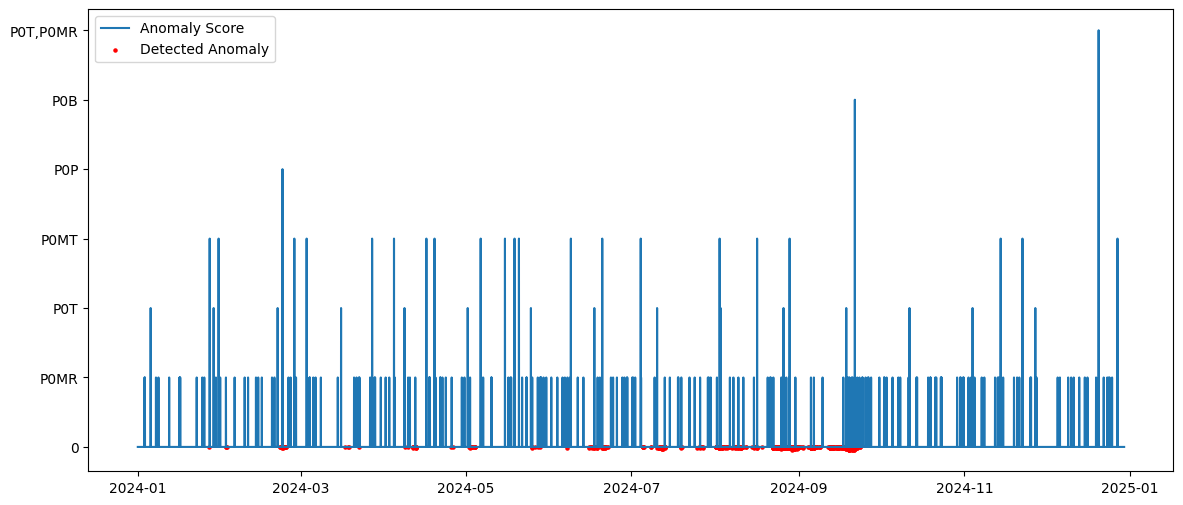

In [26]:

plt.figure(figsize=(14,6))
plt.plot(ev_test["TimeStamp"], ev_test["DTC"], label="Anomaly Score")
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "Anomaly_Score"],
            color="red", label="Detected Anomaly", s=5)
plt.legend()
plt.show()

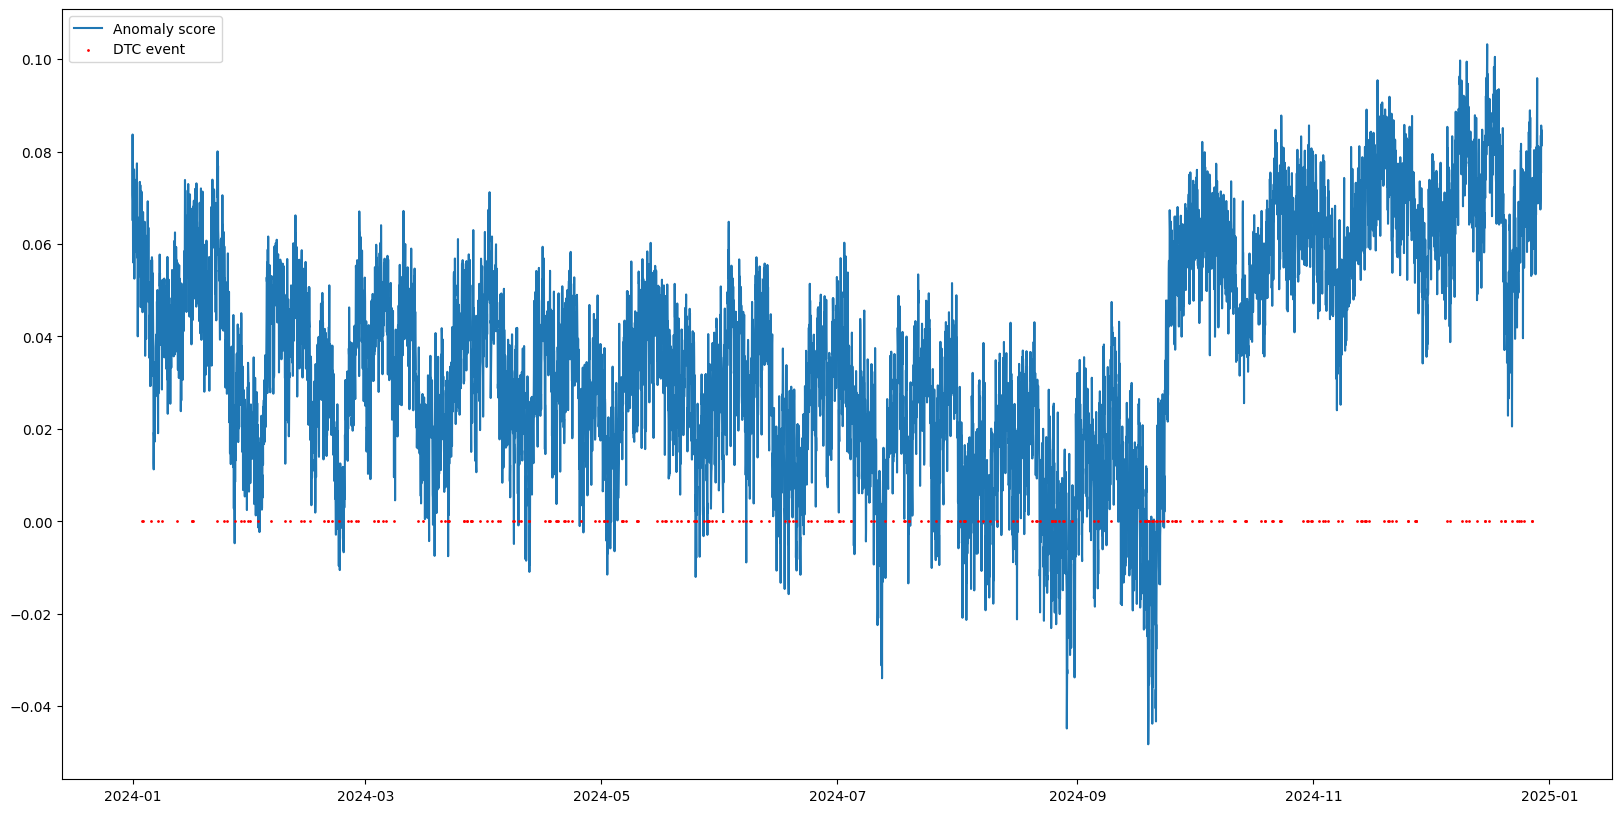

In [27]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["Anomaly_Score"], label="Anomaly score", zorder=1)
plt.scatter(ev_test.loc[ev_test["DTC"] != "0", "TimeStamp"],
            [0]*len(ev_test[ev_test["DTC"] != "0"]), color="red", label="DTC event", s=1, zorder=2)
plt.legend()
plt.show()

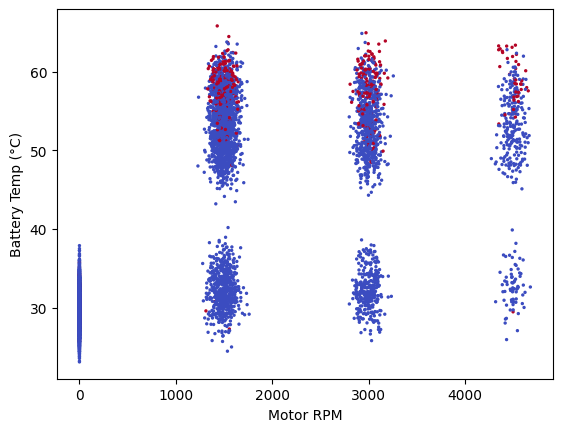

In [28]:
plt.scatter(ev_test["Motor_RPM"], ev_test["Battery_Temp"],
            c=(ev_test["Anomaly"] == -1), cmap="coolwarm", s=2)
plt.xlabel("Motor RPM")
plt.ylabel("Battery Temp (°C)")
plt.show()

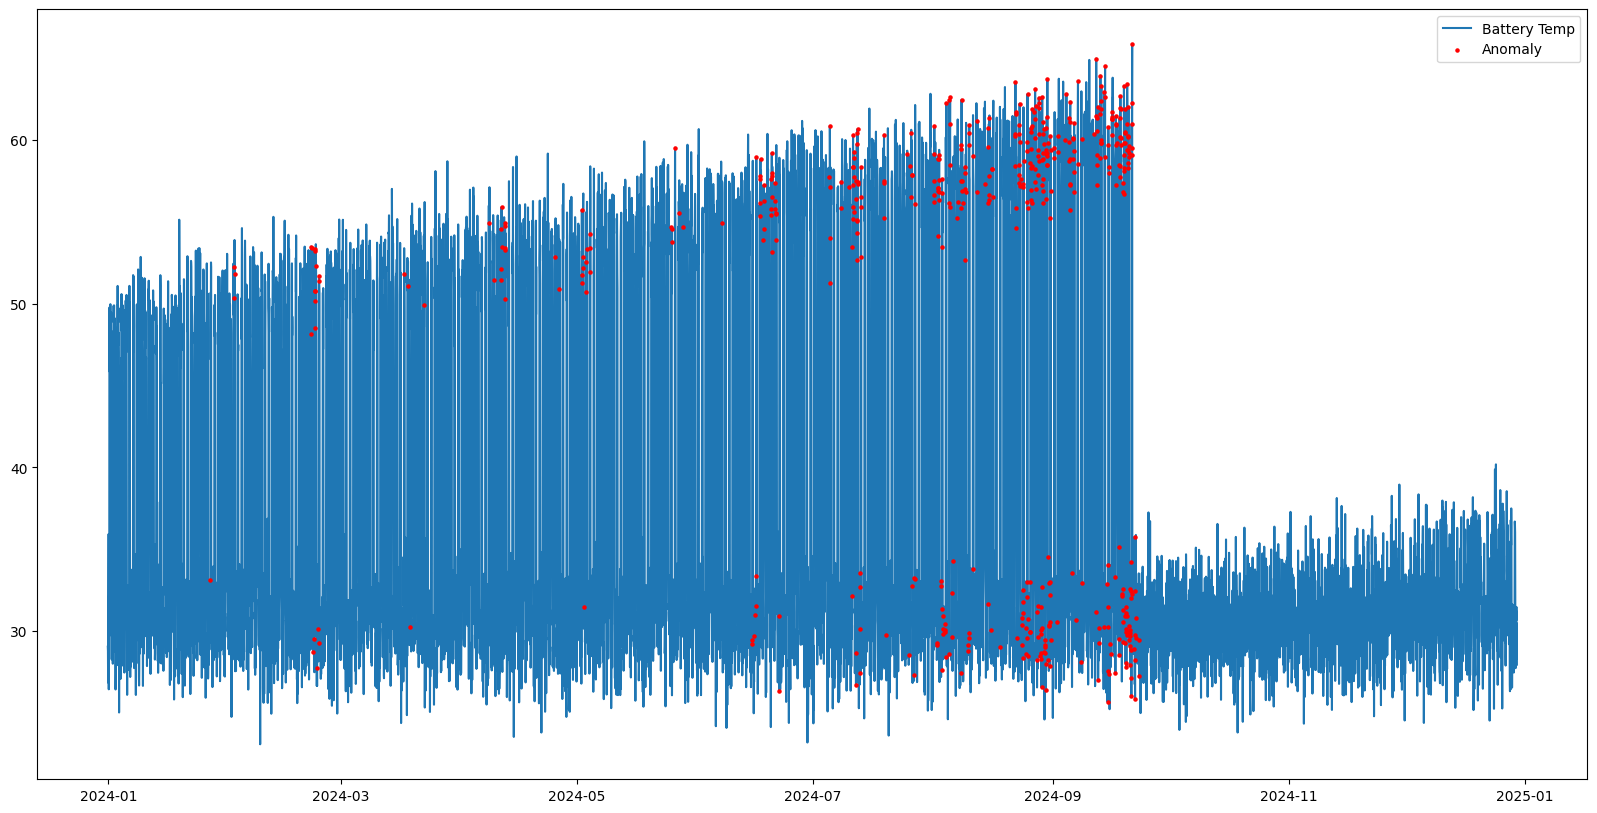

In [29]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["Battery_Temp"], label="Battery Temp", zorder=1)
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "Battery_Temp"],
            color="red", s=5, label="Anomaly", zorder=2)
plt.legend()
plt.show()

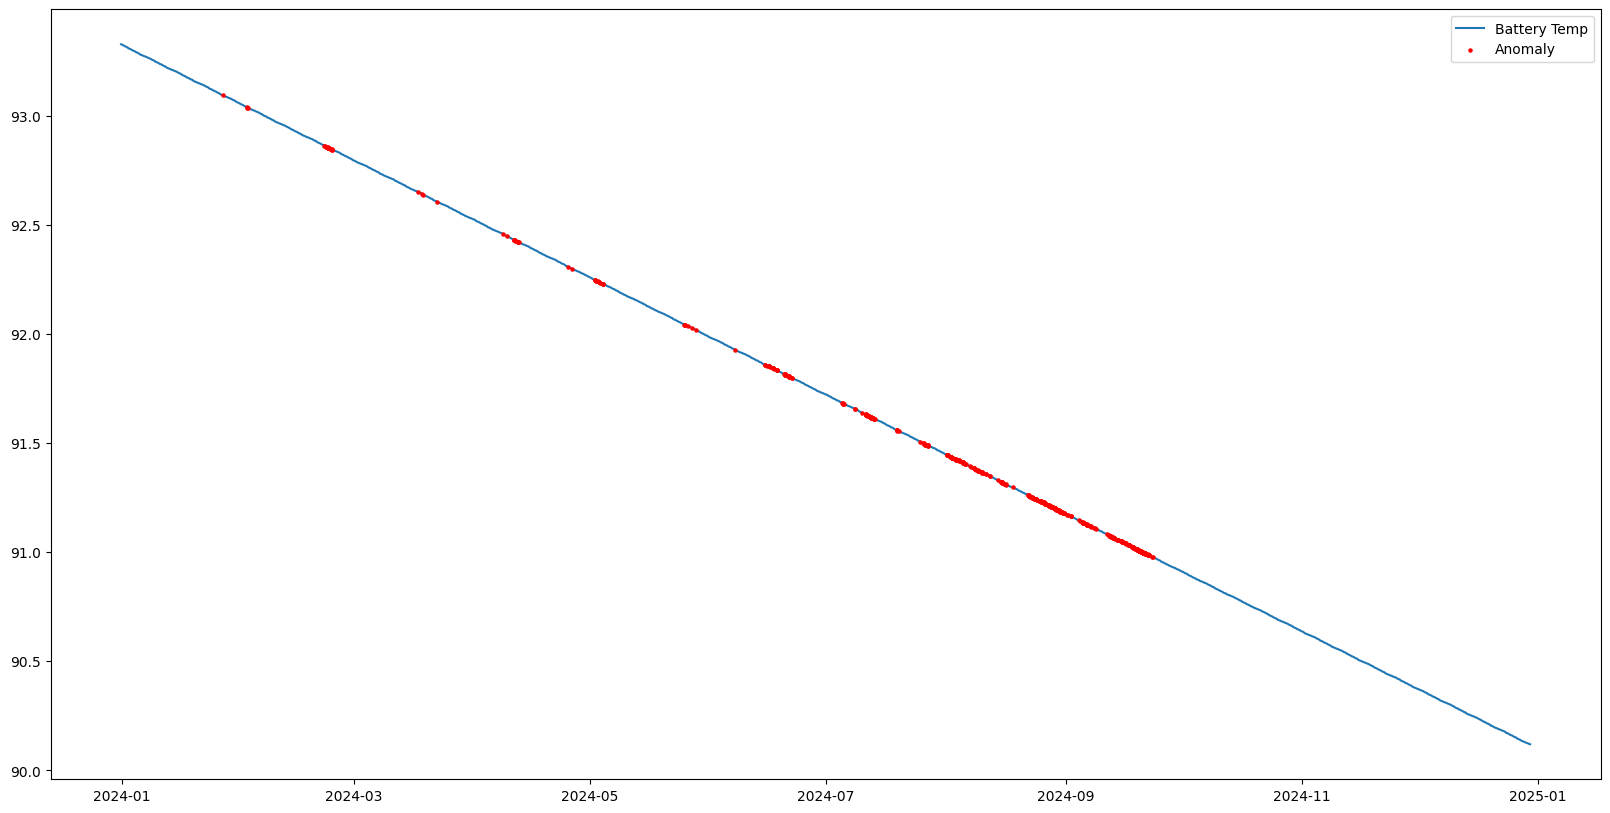

In [30]:
plt.figure(figsize=(20, 10))
plt.plot(ev_test["TimeStamp"], ev_test["SOH"], label="Battery Temp", zorder=1)
plt.scatter(ev_test.loc[ev_test["Anomaly"] == -1, "TimeStamp"],
            ev_test.loc[ev_test["Anomaly"] == -1, "SOH"],
            color="red", s=5, label="Anomaly", zorder=2)
plt.legend()
plt.show()

In [31]:
ev_test["Anomaly"].value_counts()

Anomaly
 1    8215
-1     525
Name: count, dtype: int64

In [32]:
ev_test["DTC"].value_counts()

DTC
0           8480
P0MR         221
P0MT          21
P0T           15
P0P            1
P0B            1
P0T,P0MR       1
Name: count, dtype: int64